# Step 2 — TF-IDF + Classical ML Models


Here I create a stratified 80/20 split, fit TF-IDF, train SVM / Random Forest /
XGBoost, evaluates on the full held-out test set, and saves every artifact
Promitee and Maha need for Steps 3–5.


In [1]:
import os
while not os.path.isdir("src"):
    os.chdir("..")
print("Working directory set to repo root:", os.getcwd())

Working directory set to repo root: /Users/sadmanshaharier/Documents/CODING - Mac/git repo projects/IUT-CSE/Design Project/TherapyLM-Design-Project


In [2]:
import sys
sys.path.append("src")

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from train_classical import train_all_models

## Train all three models
This runs the full Step 2 pipeline: split → TF-IDF → SVM/RF/XGBoost → evaluate → save.

In [3]:
artifacts = train_all_models(input_path="data/processed/clean.csv")

# artifacts is a dict: {"vectorizer", "svm", "rf", "xgb", "label_encoder",
#                        "train_df", "test_df", "metrics_df"}
artifacts["metrics_df"]

Train rows: 40580 | Test rows: 10146

=== SVM (LinearSVC) (full test set) ===
Accuracy 0.766 | Macro-F1 0.705 | Weighted-F1 0.764
                      precision    recall  f1-score   support

             Anxiety       0.77      0.79      0.78       722
             Bipolar       0.78      0.74      0.76       500
          Depression       0.75      0.68      0.71      3017
              Normal       0.89      0.94      0.91      3143
Personality disorder       0.60      0.53      0.56       179
              Stress       0.52      0.54      0.53       457
            Suicidal       0.67      0.70      0.69      2128

            accuracy                           0.77     10146
           macro avg       0.71      0.70      0.71     10146
        weighted avg       0.76      0.77      0.76     10146


=== Random Forest (full test set) ===
Accuracy 0.729 | Macro-F1 0.659 | Weighted-F1 0.724
                      precision    recall  f1-score   support

             Anxiety       0.73

,model,accuracy,macro_f1,weighted_f1
0,SVM (LinearSVC),0.766312,0.705273,0.764383
1,Random Forest,0.729351,0.658705,0.723697
2,XGBoost,0.770057,0.709379,0.765998


## Results chart
Side-by-side accuracy and macro-F1 for the three models

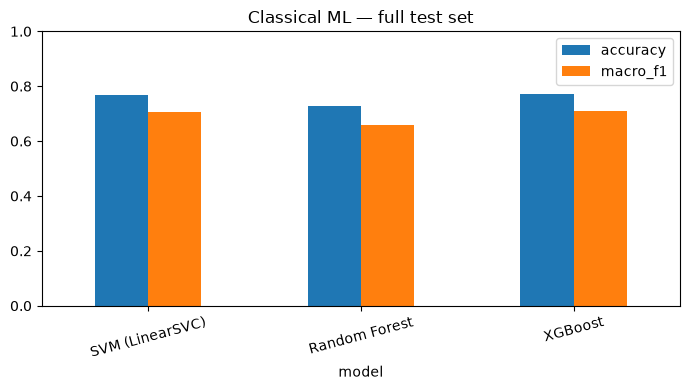

In [4]:
os.makedirs("results/figures", exist_ok=True)
metrics_df = artifacts["metrics_df"]
ax = metrics_df.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(7, 4))
ax.set_ylim(0, 1)
ax.set_title("Classical ML — full test set")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results/figures/classical_ml_results.png", dpi=120)
plt.show()

## Compare to the paper (Table II)
| Model | Paper Acc | Paper Macro-F1 |
|---|---|---|
| SVM | 0.768 | 0.734 |
| Random Forest | 0.712 | 0.626 |
| XGBoost | 0.776 | 0.741 |



## Done
Saved: `models/*.joblib`, `data/processed/train.csv` + `test.csv`, `results/tables/full_test_metrics.csv`.

